# EV08 - Generacion de visualizaciones en Matplotlib


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

ruta_dataset = "../data/raw/dataset.csv"
df = pd.read_csv(ruta_dataset)

output_dir = Path("../artifacts/ev08")
output_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", ruta_dataset)
print("Dimensiones:", df.shape)
print("Directorio de exportaciones:", output_dir.resolve())


Dataset: ../data/raw/dataset.csv
Dimensiones: (16598, 11)
Directorio de exportaciones: C:\Users\braya\Documents\proyectos\pruebas\proyecto_ds\artifacts\ev08


## A) Estructura de una grafica

Replicacion:
- Crear una Figura con `plt.figure()` y con `plt.subplots()`.
- Crear ejes con `add_subplot()`.
- Anadir titulo, etiquetas, leyendas y anotaciones.


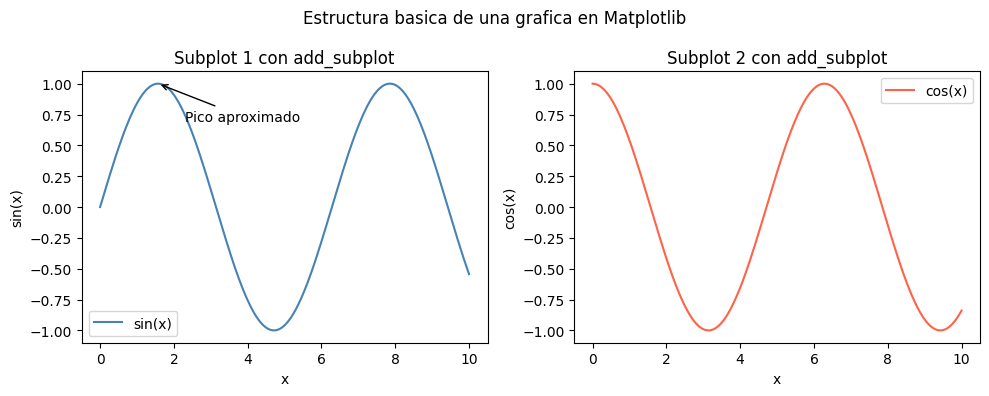

In [2]:
# A1: Estructura con plt.figure() + add_subplot()
x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.plot(x, y1, label='sin(x)', color='steelblue')
ax1.set_title('Subplot 1 con add_subplot')
ax1.set_xlabel('x')
ax1.set_ylabel('sin(x)')
ax1.legend()
ax1.annotate('Pico aproximado', xy=(1.57, 1), xytext=(2.3, 0.7),
             arrowprops=dict(arrowstyle='->', color='black'))

ax2.plot(x, y2, label='cos(x)', color='tomato')
ax2.set_title('Subplot 2 con add_subplot')
ax2.set_xlabel('x')
ax2.set_ylabel('cos(x)')
ax2.legend()

fig.suptitle('Estructura basica de una grafica en Matplotlib')
fig.tight_layout()
fig.savefig(output_dir / 'A1_estructura_add_subplot.png', dpi=160, bbox_inches='tight')
plt.show()


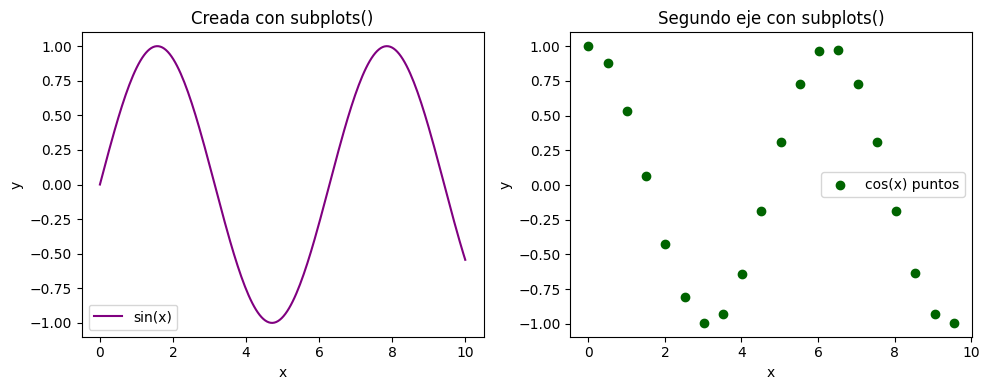

In [3]:
# A2: Estructura con plt.subplots()
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(x, y1, color='purple', label='sin(x)')
axs[0].set_title('Creada con subplots()')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].legend()

axs[1].scatter(x[::10], y2[::10], color='darkgreen', label='cos(x) puntos')
axs[1].set_title('Segundo eje con subplots()')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / 'A2_estructura_subplots.pdf', bbox_inches='tight')
plt.show()


## B) Interfaz Pyplot vs OO


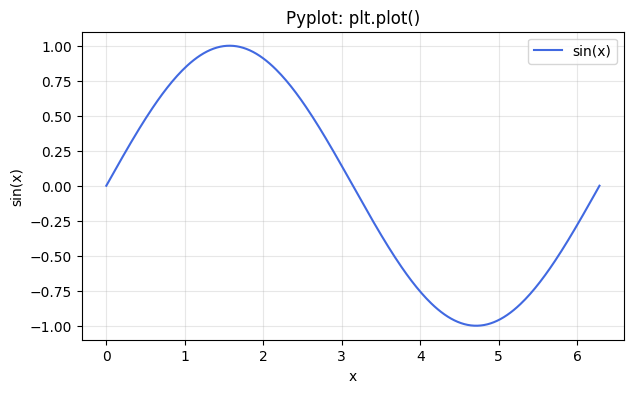

In [4]:
# B1: Ejemplo con interfaz pyplot
x = np.linspace(0, 2 * np.pi, 300)
plt.figure(figsize=(7, 4))
plt.plot(x, np.sin(x), label='sin(x)', color='royalblue')
plt.title('Pyplot: plt.plot()')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


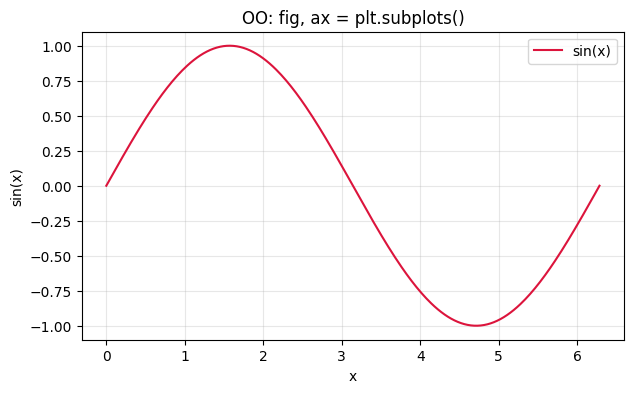

In [5]:
# B2: Ejemplo con API orientada a objetos (OO)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x), label='sin(x)', color='crimson')
ax.set_title('OO: fig, ax = plt.subplots()')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## C) Graficas univariantes (Replicar TODOS)


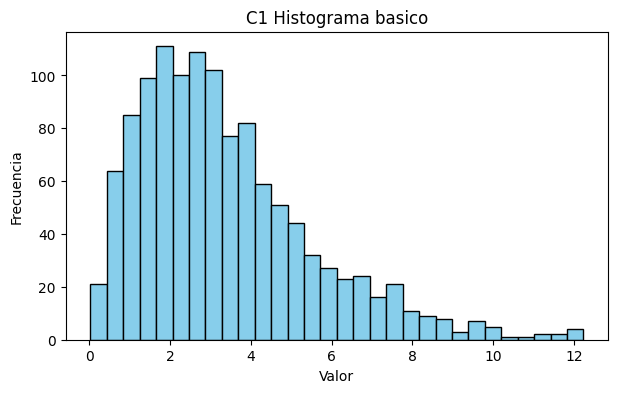

In [6]:
# Datos univariantes
ventas = np.random.gamma(shape=2.2, scale=1.5, size=1200)

# C1 Histograma basico
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ventas, bins=30, color='skyblue', edgecolor='black')
ax.set_title('C1 Histograma basico')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
fig.savefig(output_dir / 'C1_histograma_basico.png', dpi=160, bbox_inches='tight')
plt.show()


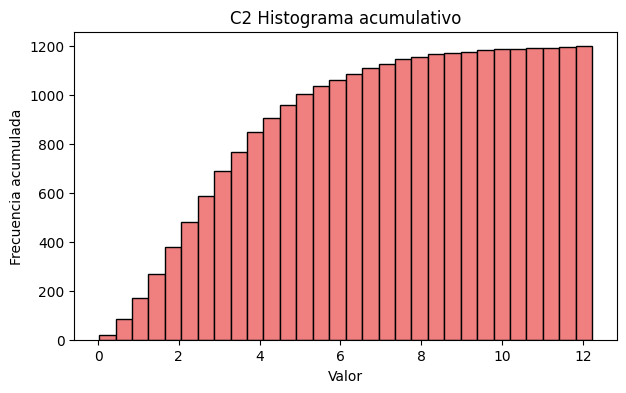

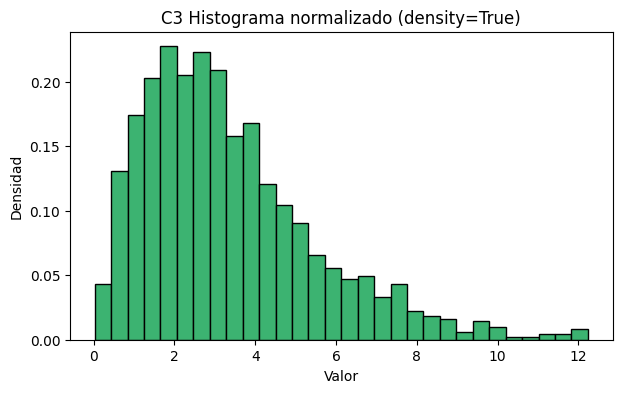

In [7]:
# C2 Histograma acumulativo
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ventas, bins=30, cumulative=True, color='lightcoral', edgecolor='black')
ax.set_title('C2 Histograma acumulativo')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia acumulada')
plt.show()

# C3 Histograma normalizado
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ventas, bins=30, density=True, color='mediumseagreen', edgecolor='black')
ax.set_title('C3 Histograma normalizado (density=True)')
ax.set_xlabel('Valor')
ax.set_ylabel('Densidad')
plt.show()


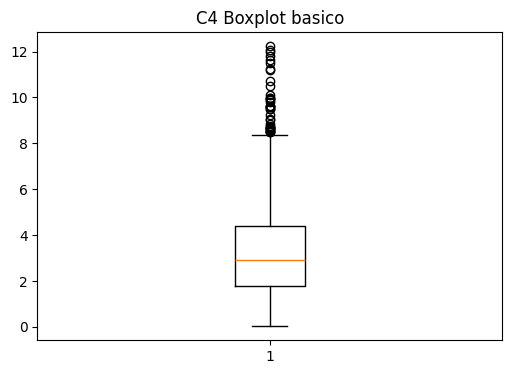

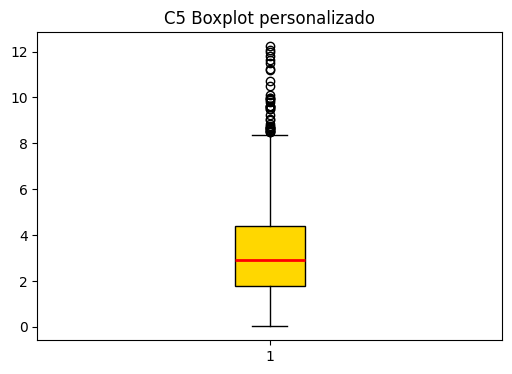

In [8]:
# C4 Boxplot basico
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(ventas)
ax.set_title('C4 Boxplot basico')
plt.show()

# C5 Boxplot personalizado con colores
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    ventas,
    patch_artist=True,
    boxprops=dict(facecolor='gold', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)
ax.set_title('C5 Boxplot personalizado')
plt.show()


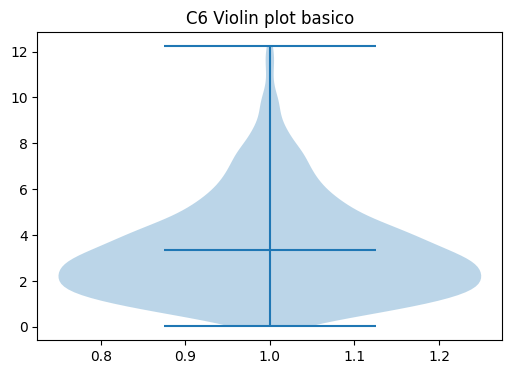

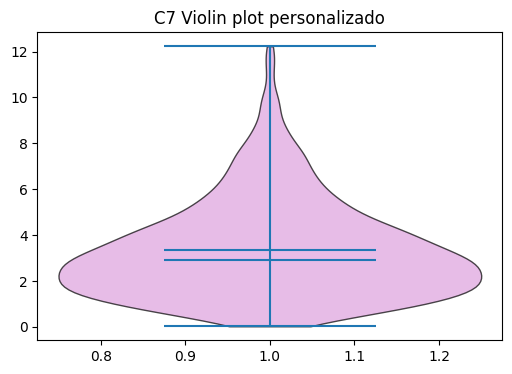

In [9]:
# C6 Violin plot basico
fig, ax = plt.subplots(figsize=(6, 4))
ax.violinplot(ventas, showmeans=True)
ax.set_title('C6 Violin plot basico')
plt.show()

# C7 Violin plot personalizado
fig, ax = plt.subplots(figsize=(6, 4))
vp = ax.violinplot(ventas, showmeans=True, showmedians=True)
for body in vp['bodies']:
    body.set_facecolor('plum')
    body.set_edgecolor('black')
    body.set_alpha(0.7)
ax.set_title('C7 Violin plot personalizado')
plt.show()


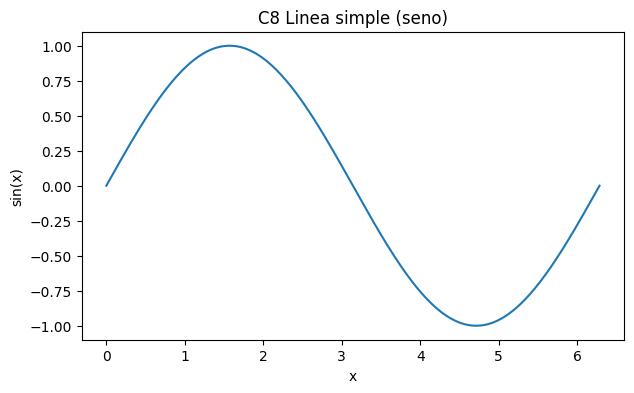

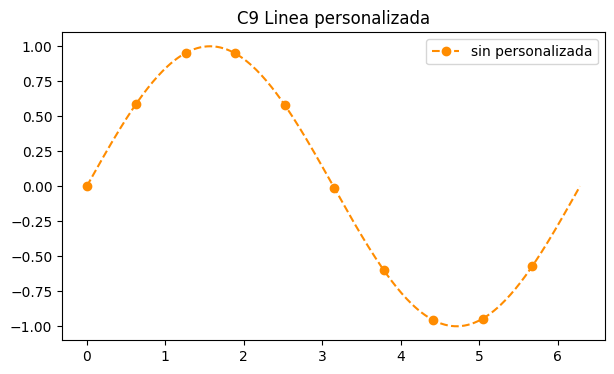

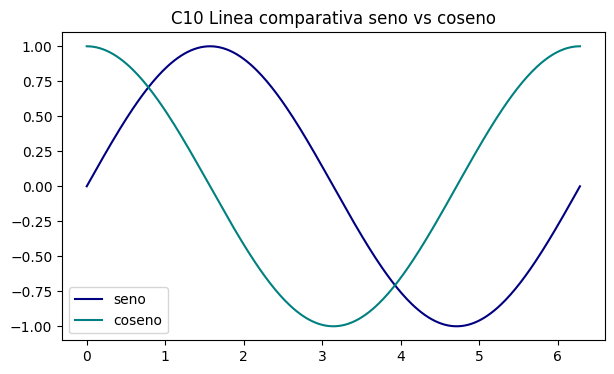

In [10]:
# C8 Grafica de linea simple (seno)
x = np.linspace(0, 2 * np.pi, 300)
y_sin = np.sin(x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_sin)
ax.set_title('C8 Linea simple (seno)')
ax.set_xlabel('x')
ax.set_ylabel('sin(x)')
plt.show()

# C9 Lineas personalizadas
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_sin, color='darkorange', linestyle='--', marker='o', markevery=30, label='sin personalizada')
ax.set_title('C9 Linea personalizada')
ax.legend()
plt.show()

# C10 Linea comparativa (seno vs coseno)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x), label='seno', color='navy')
ax.plot(x, np.cos(x), label='coseno', color='teal')
ax.set_title('C10 Linea comparativa seno vs coseno')
ax.legend()
fig.savefig(output_dir / 'C10_seno_coseno.png', dpi=160, bbox_inches='tight')
plt.show()


## D) Graficas bivariantes (Replicar TODOS)


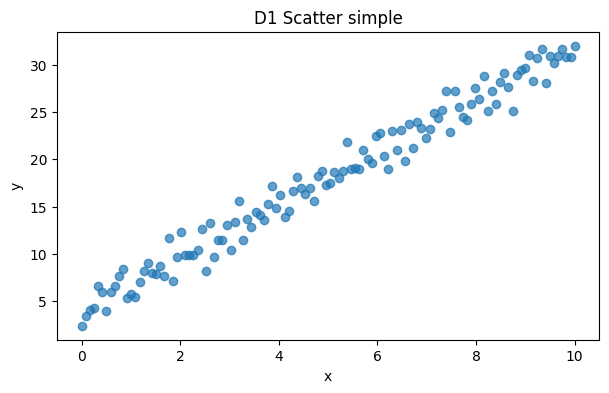

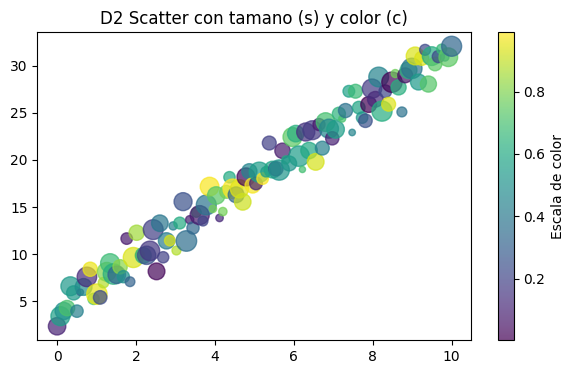

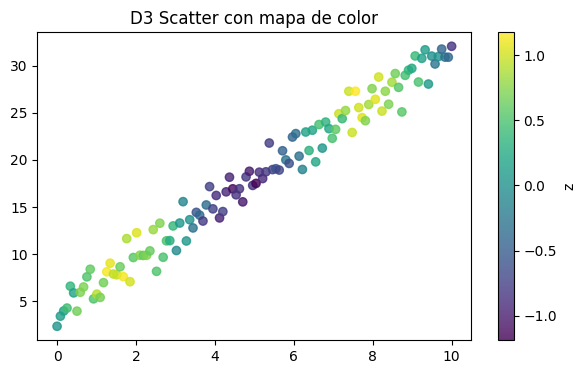

In [11]:
# Datos bivariantes base
x = np.linspace(0, 10, 120)
noise = np.random.normal(0, 1.3, size=len(x))
y = 2.8 * x + 4 + noise

# D1 Scatter simple
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, alpha=0.7)
ax.set_title('D1 Scatter simple')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

# D2 Scatter con tamano y color
tam = np.random.randint(20, 220, size=len(x))
col = np.random.rand(len(x))
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(x, y, s=tam, c=col, alpha=0.7)
ax.set_title('D2 Scatter con tamano (s) y color (c)')
fig.colorbar(sc, ax=ax, label='Escala de color')
plt.show()

# D3 Scatter con mapa de color
z = np.sin(x) + np.random.normal(0, 0.15, size=len(x))
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(x, y, c=z, cmap='viridis', alpha=0.8)
ax.set_title('D3 Scatter con mapa de color')
fig.colorbar(sc, ax=ax, label='z')
plt.show()


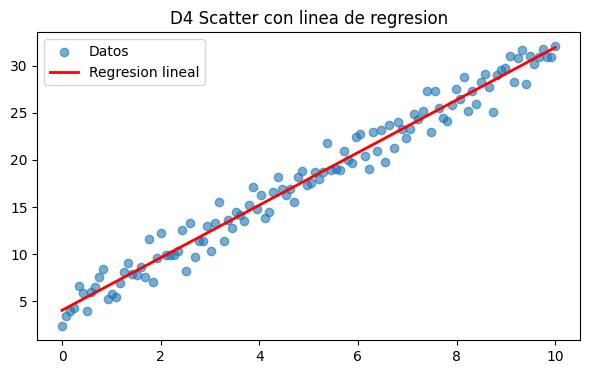

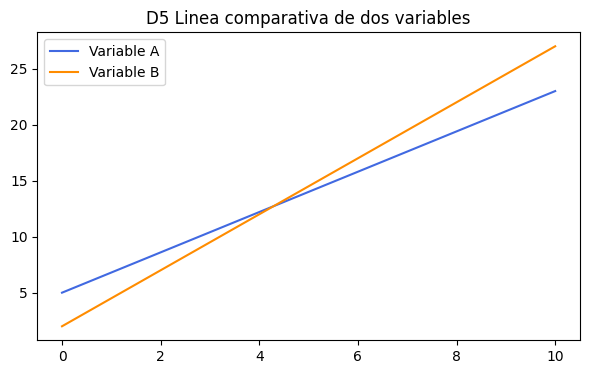

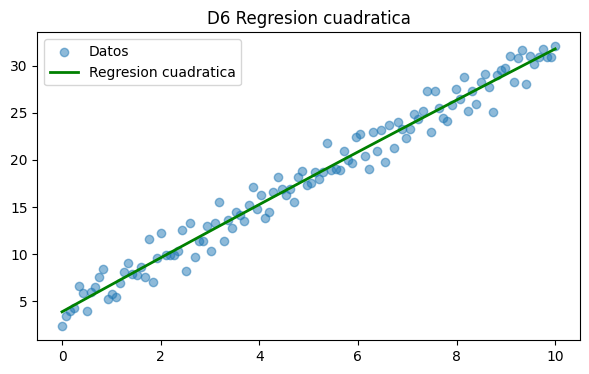

In [12]:
# D4 Scatter con linea de regresion lineal
coef_lin = np.polyfit(x, y, 1)
y_lin = np.polyval(coef_lin, x)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, alpha=0.6, label='Datos')
ax.plot(x, y_lin, color='red', linewidth=2, label='Regresion lineal')
ax.set_title('D4 Scatter con linea de regresion')
ax.legend()
plt.show()

# D5 Linea comparativa de dos variables
y_a = 1.8 * x + 5
y_b = 2.5 * x + 2
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_a, label='Variable A', color='royalblue')
ax.plot(x, y_b, label='Variable B', color='darkorange')
ax.set_title('D5 Linea comparativa de dos variables')
ax.legend()
plt.show()

# D6 Linea con regresion cuadratica
coef_quad = np.polyfit(x, y, 2)
y_quad = np.polyval(coef_quad, x)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x, y, alpha=0.5, label='Datos')
ax.plot(x, y_quad, color='green', linewidth=2, label='Regresion cuadratica')
ax.set_title('D6 Regresion cuadratica')
ax.legend()
fig.savefig(output_dir / 'D6_regresion_cuadratica.png', dpi=160, bbox_inches='tight')
plt.show()


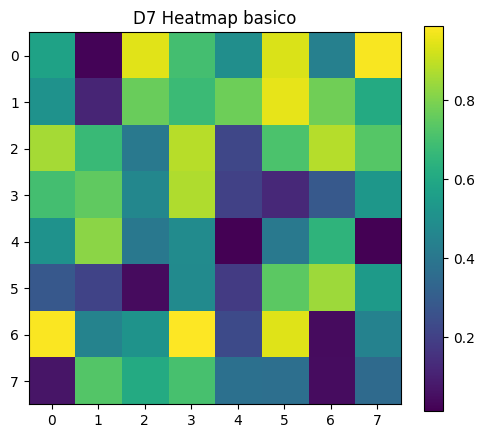

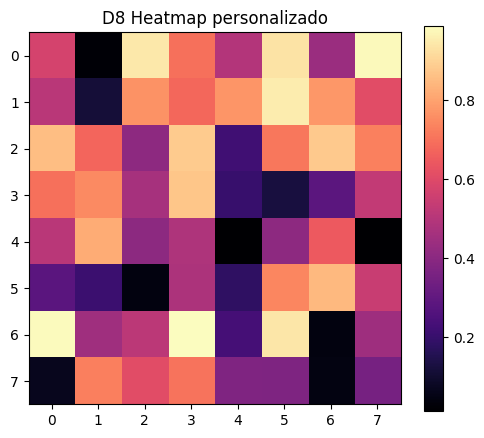

In [13]:
# D7 Heatmap basico con imshow()
matriz = np.random.rand(8, 8)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz)
ax.set_title('D7 Heatmap basico')
fig.colorbar(im, ax=ax)
plt.show()

# D8 Heatmap personalizado (cmap, ticks, interpolacion)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz, cmap='magma', interpolation='nearest')
ax.set_xticks(range(matriz.shape[1]))
ax.set_yticks(range(matriz.shape[0]))
ax.set_title('D8 Heatmap personalizado')
fig.colorbar(im, ax=ax)
plt.show()


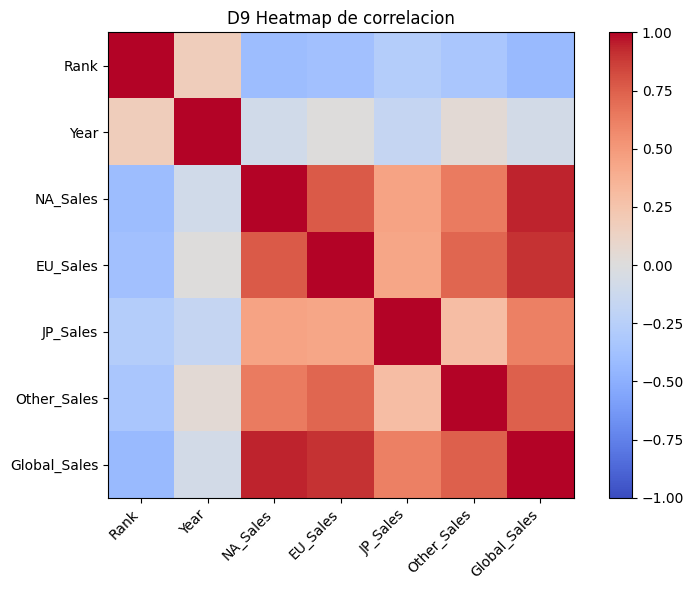

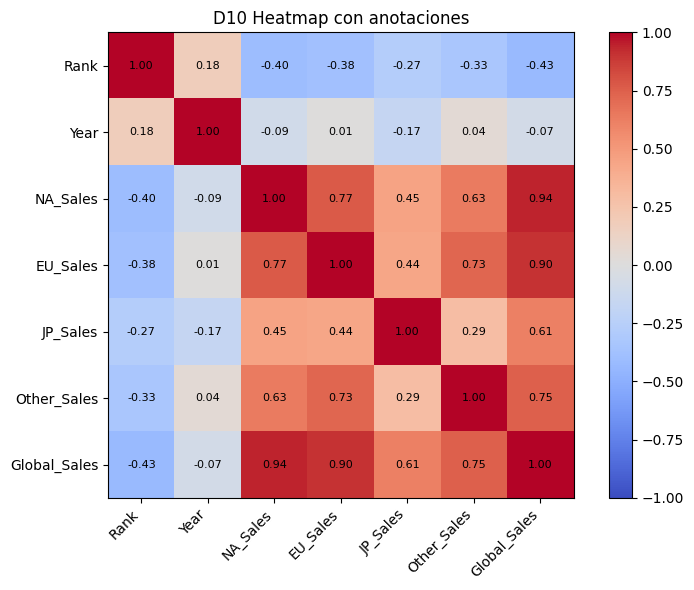

In [14]:
# D9 Heatmap de matriz de correlacion (dataset real)
corr = df[['Rank','Year','NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
ax.set_title('D9 Heatmap de correlacion')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# D10 Heatmap con anotaciones numericas
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', color='black', fontsize=8)

ax.set_title('D10 Heatmap con anotaciones')
fig.colorbar(im, ax=ax)
plt.tight_layout()
fig.savefig(output_dir / 'D10_heatmap_anotado.pdf', bbox_inches='tight')
plt.show()


## E) Graficas categoricas (Replicar TODOS)


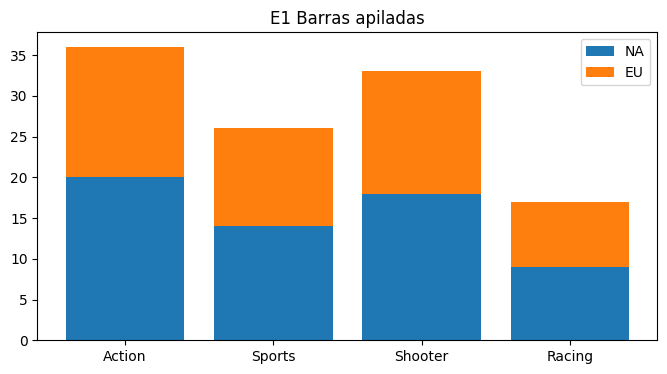

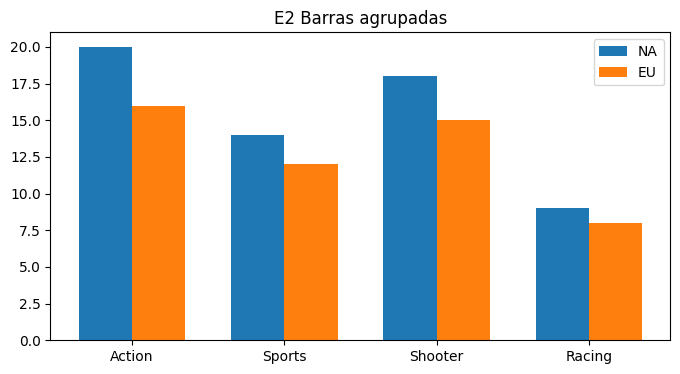

In [15]:
categorias = ['Action', 'Sports', 'Shooter', 'Racing']
na_vals = np.array([20, 14, 18, 9])
eu_vals = np.array([16, 12, 15, 8])

# E1 Barras apiladas
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(categorias, na_vals, label='NA')
ax.bar(categorias, eu_vals, bottom=na_vals, label='EU')
ax.set_title('E1 Barras apiladas')
ax.legend()
plt.show()

# E2 Barras agrupadas
xpos = np.arange(len(categorias))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xpos - width/2, na_vals, width, label='NA')
ax.bar(xpos + width/2, eu_vals, width, label='EU')
ax.set_xticks(xpos)
ax.set_xticklabels(categorias)
ax.set_title('E2 Barras agrupadas')
ax.legend()
plt.show()


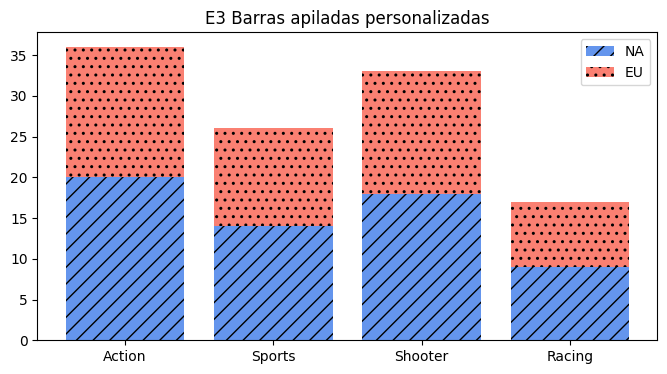

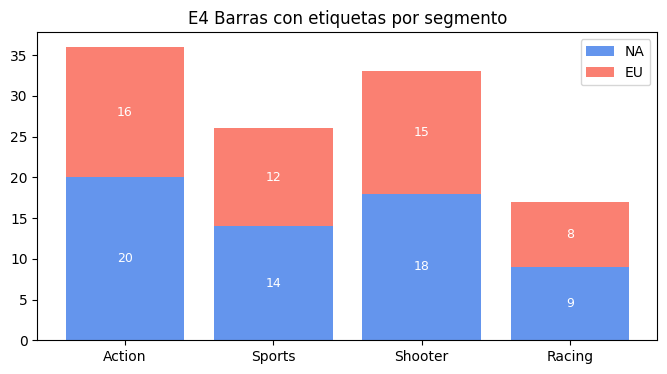

In [16]:
# E3 Barras apiladas personalizadas (colores, hatch)
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(categorias, na_vals, label='NA', color='cornflowerblue', hatch='//')
b2 = ax.bar(categorias, eu_vals, bottom=na_vals, label='EU', color='salmon', hatch='..')
ax.set_title('E3 Barras apiladas personalizadas')
ax.legend()
plt.show()

# E4 Barras con etiquetas numericas sobre cada segmento
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(categorias, na_vals, label='NA', color='cornflowerblue')
b2 = ax.bar(categorias, eu_vals, bottom=na_vals, label='EU', color='salmon')

for rect in b1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h/2, f'{h}', ha='center', va='center', color='white', fontsize=9)

for rect, base in zip(b2, na_vals):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, base + h/2, f'{h}', ha='center', va='center', color='white', fontsize=9)

ax.set_title('E4 Barras con etiquetas por segmento')
ax.legend()
fig.savefig(output_dir / 'E4_barras_etiquetas.png', dpi=160, bbox_inches='tight')
plt.show()


## Exportaciones realizadas con savefig()

Se guardaron archivos en `../artifacts/ev08/` en formato `.png` y `.pdf` como evidencia de exportacion.


In [17]:
exportados = sorted([p.name for p in output_dir.glob('*')])
print('Total de archivos exportados:', len(exportados))
for nombre in exportados:
    print('-', nombre)


Total de archivos exportados: 7
- A1_estructura_add_subplot.png
- A2_estructura_subplots.pdf
- C10_seno_coseno.png
- C1_histograma_basico.png
- D10_heatmap_anotado.pdf
- D6_regresion_cuadratica.png
- E4_barras_etiquetas.png


## Reflexion tecnica

1. **Cual grafica fue mas util para interpretar datos y por que?**
La grafica de correlacion (heatmap) fue la mas util porque permite ver de forma compacta la relacion entre varias variables numericas del dataset y detectar rapidamente asociaciones fuertes o debiles.

2. **Que diferencias notaste entre usar pyplot y la API OO?**
`pyplot` es rapido para ejemplos simples y pruebas cortas. La API OO es mas controlable y escalable para notebooks largos, especialmente cuando hay multiples subplots y configuraciones por eje.

3. **Que tipo de grafica consideras mas adecuada para tu proyecto personal?**
Para el dataset de videojuegos, una combinacion de barras (comparar categorias), lineas (tendencias por ano) y dispersion/correlacion (relaciones entre ventas regionales) es la opcion mas adecuada.


## Checklist final EV08

- [x] Documento conceptual creado.
- [x] Notebook con ejercicios A-E replicados.
- [x] Comentarios y estructura organizada.
- [x] Graficas renderizadas.
- [x] Exportaciones con savefig() generadas.
